
Processing context length: 128
CausalRevIN_True vs CausalRevIN_True - MSE: 0.0000, MAE: 0.0000, MASE: 0.0000
CausalRevIN_True vs CausalRevIN_False - MSE: -0.2415, MAE: -0.2689, MASE: -0.0989
CausalRevIN_True vs PrefixRevIN_True - MSE: -0.4372, MAE: -0.4884, MASE: -0.1445
CausalRevIN_True vs PrefixRevIN_False - MSE: -0.3289, MAE: -0.3510, MASE: -0.1011
CausalRevIN_True vs RevIN_True - MSE: -0.4339, MAE: -0.4620, MASE: -0.1911
CausalRevIN_True vs RevIN_False - MSE: -0.4366, MAE: -0.4667, MASE: -0.1879
CausalRevIN_False vs CausalRevIN_True - MSE: 0.1945, MAE: 0.2119, MASE: 0.0900
CausalRevIN_False vs CausalRevIN_False - MSE: 0.0000, MAE: 0.0000, MASE: 0.0000
CausalRevIN_False vs PrefixRevIN_True - MSE: -0.1577, MAE: -0.1730, MASE: -0.0416
CausalRevIN_False vs PrefixRevIN_False - MSE: -0.0704, MAE: -0.0648, MASE: -0.0021
CausalRevIN_False vs RevIN_True - MSE: -0.1550, MAE: -0.1522, MASE: -0.0840
CausalRevIN_False vs RevIN_False - MSE: -0.1572, MAE: -0.1559, MASE: -0.0811
PrefixRevIN_True 

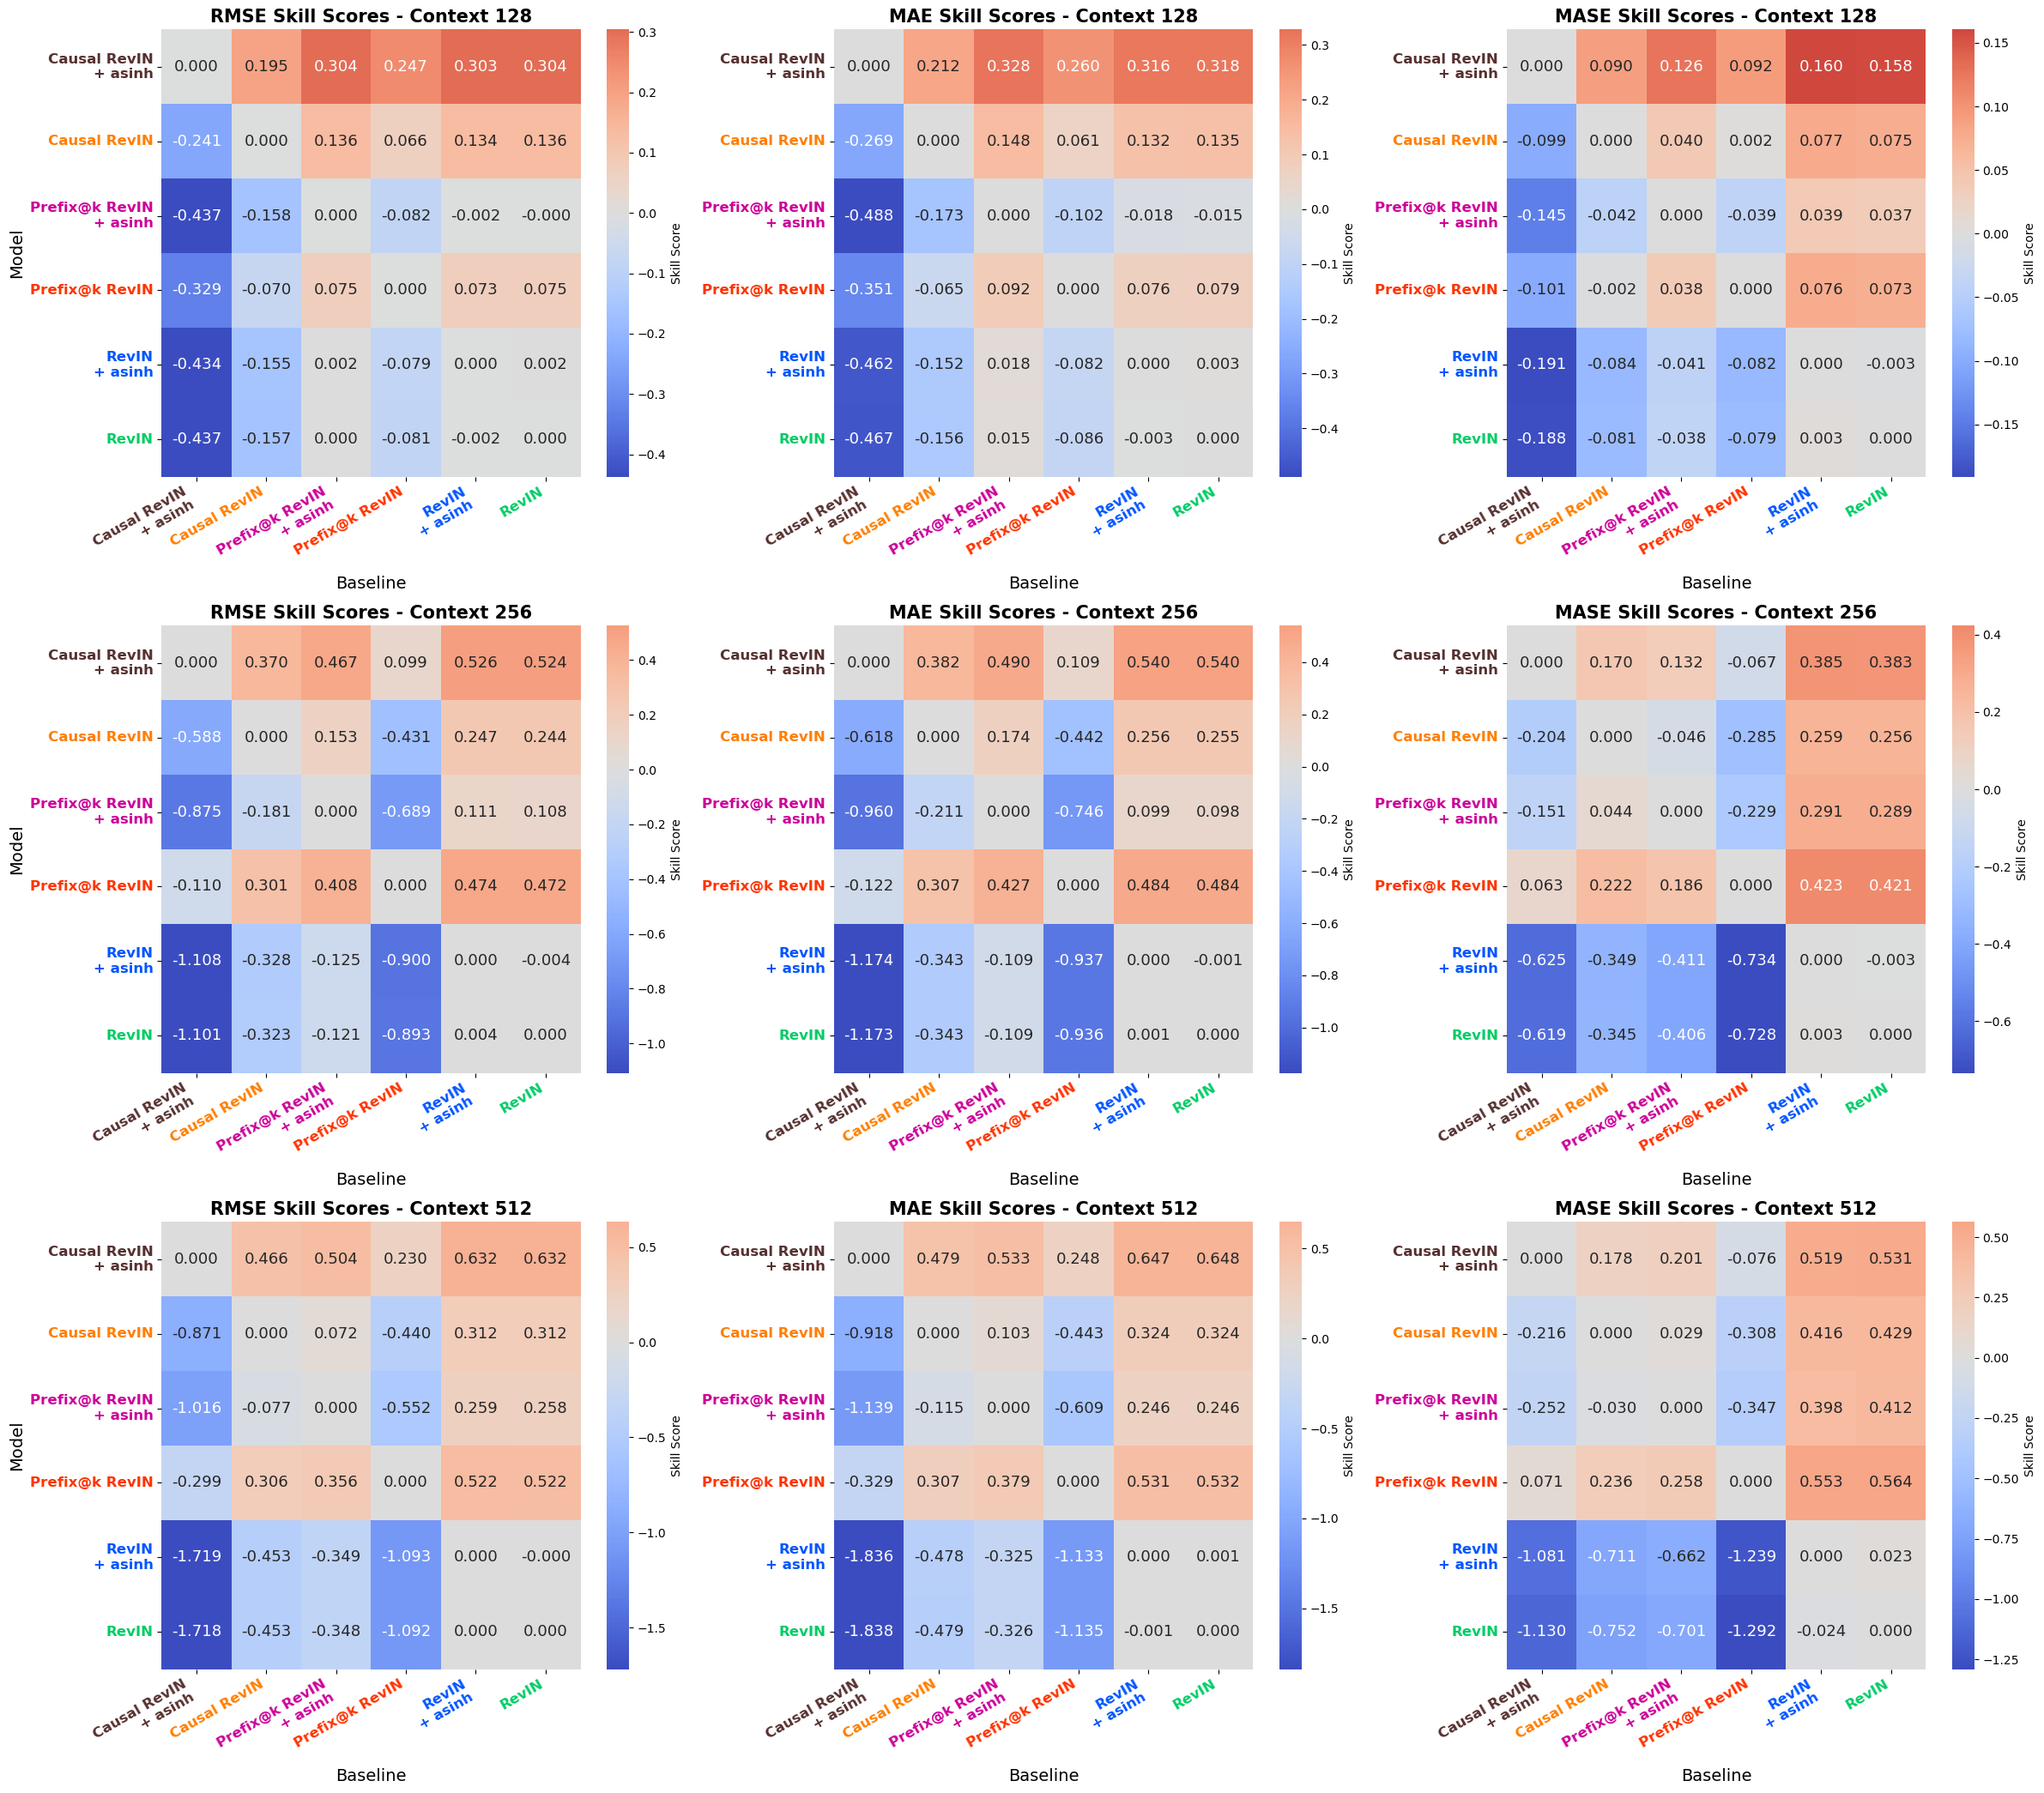

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

model_name_to_show_label = {
    "CausalRevIN_True": "Causal RevIN + asinh",
    "CausalRevIN_False": "Causal RevIN",
    "RevIN_True": "RevIN + asinh",
    "RevIN_False": "RevIN",
    "PrefixRevIN_True": "Prefix@k RevIN + asinh",
    "PrefixRevIN_False": "Prefix@k RevIN"
}

dic_model_colors = {
    "Causal RevIN":          "#FF7F00",  # vivid orange
    "Causal RevIN + asinh":  "#573030FF",  # semi-transparent brown
    "RevIN":                 "#00CC66",  # vivid green
    "RevIN + asinh":         "#0055FF",  # electric deep blue
    "Prefix@k RevIN":        "#FF3300",  # bright red-orange
    "Prefix@k RevIN + asinh": "#CC0099",  # strong magenta
}

def load_npz(filepath):
    """Load npz file and return as dictionary"""
    return np.load(filepath)

# Model names
models = ["CausalRevIN_True", "CausalRevIN_False", "PrefixRevIN_True", 
          "PrefixRevIN_False", "RevIN_True", "RevIN_False"]

context_lengths = ["128", "256", "512"]
datasets = ["utsd", "gift_eval", "artificial"]

# Dictionary to store matrices for each context length
all_skill_scores = {
    'mse': {},
    'mae': {},
    'mase': {}
}

# Iterate through all context lengths
for context in context_lengths:
    print(f"\n{'='*50}")
    print(f"Processing context length: {context}")
    print(f"{'='*50}")
    
    # Initialize matrices to store skill scores
    skill_scores_mse_matrix = np.zeros((len(models), len(models)))
    skill_scores_mae_matrix = np.zeros((len(models), len(models)))
    skill_scores_mase_matrix = np.zeros((len(models), len(models)))
    
    # Iterate through all baseline-comparison pairs
    for i, baseline in enumerate(models):
        for j, comparison in enumerate(models):
            mse_baseline = []
            mae_baseline = []
            mase_baseline = []
            mse_comparison = []
            mae_comparison = []
            mase_comparison = []
            
            # Load data for each dataset
            for dataset in datasets:
                try:
                    r_baseline = load_npz(f'../processed_results/{baseline}/{context}/results_{dataset}.npz')
                    r_comparison = load_npz(f'../processed_results/{comparison}/{context}/results_{dataset}.npz')
                    
                    # Process metrics
                    for k1, k2 in zip(r_baseline, r_comparison):
                        assert k1 == k2, "Predictions do not match"
                        metric = k1.split("_")[0].lower()
                        
                        if metric == "rmse":
                            mse_baseline.append(r_baseline[k1].item())
                            mse_comparison.append(r_comparison[k2].item())
                        elif metric == "mae":
                            mae_baseline.append(r_baseline[k1].item())
                            mae_comparison.append(r_comparison[k2].item())
                        else:
                            mase_baseline.append(r_baseline[k1].item())
                            mase_comparison.append(r_comparison[k2].item())
                except FileNotFoundError:
                    print(f"Warning: Files not found for {baseline} or {comparison} on {dataset}")
                    continue
            
            # Calculate MSE skill score
            if len(mse_baseline) > 0 and len(mse_comparison) > 0:
                scores_mse = []
                for p1, p2 in zip(mse_baseline, mse_comparison):
                    scores_mse.append(p2/p1)
                scores_mse = np.array(scores_mse)
                scores_mse = np.clip(scores_mse, 0.01, 100)
                n = len(scores_mse)
                produit = np.prod(scores_mse)
                geometric_mean = produit ** (1/n)
                skill_scores_mse = 1 - geometric_mean
                skill_scores_mse_matrix[i, j] = skill_scores_mse
            
            # Calculate MAE skill score
            if len(mae_baseline) > 0 and len(mae_comparison) > 0:
                scores_mae = []
                for p1, p2 in zip(mae_baseline, mae_comparison):
                    scores_mae.append(p2/p1)
                scores_mae = np.array(scores_mae)
                scores_mae = np.clip(scores_mae, 0.01, 100)
                n = len(scores_mae)
                produit = np.prod(scores_mae)
                geometric_mean = produit ** (1/n)
                skill_scores_mae = 1 - geometric_mean
                skill_scores_mae_matrix[i, j] = skill_scores_mae
            
            # Calculate MASE skill score
            if len(mase_baseline) > 0 and len(mase_comparison) > 0:
                scores_mase = []
                for p1, p2 in zip(mase_baseline, mase_comparison):
                    scores_mase.append(p2/p1)
                scores_mase = np.array(scores_mase)
                scores_mase = np.clip(scores_mase, 0.01, 100)
                n = len(scores_mase)
                produit = np.prod(scores_mase)
                geometric_mean = produit ** (1/n)
                skill_scores_mase = 1 - geometric_mean
                skill_scores_mase_matrix[i, j] = skill_scores_mase
            
            print(f"{baseline} vs {comparison} - MSE: {skill_scores_mse_matrix[i,j]:.4f}, "
                  f"MAE: {skill_scores_mae_matrix[i,j]:.4f}, MASE: {skill_scores_mase_matrix[i,j]:.4f}")
    
    # Store matrices for this context length (transposed so y=comparison, x=baseline)
    all_skill_scores['mse'][context] = skill_scores_mse_matrix.T
    all_skill_scores['mae'][context] = skill_scores_mae_matrix.T
    all_skill_scores['mase'][context] = skill_scores_mase_matrix.T

# Create heatmaps - 3 rows (context lengths) x 3 columns (metrics)
fig, axes = plt.subplots(len(context_lengths), 3, figsize=(24, 7*len(context_lengths)))

# Map model names to display labels (split long names with + asinh into two rows)
display_names = []
for m in models:
    label = model_name_to_show_label[m]
    if '+ asinh' in label:
        # Split into two rows
        label = label.replace(' + asinh', '\n+ asinh')
    display_names.append(label)

# Plot heatmaps for each context length
for row_idx, context in enumerate(context_lengths):
    # MSE Heatmap (transposed: y=comparison, x=baseline)
    sns.heatmap(all_skill_scores['mse'][context], annot=True, fmt='.3f', cmap='coolwarm', 
                xticklabels=display_names, yticklabels=display_names, 
                center=0, ax=axes[row_idx, 0], cbar_kws={'label': 'Skill Score'},
                annot_kws={'fontsize': 13})
    axes[row_idx, 0].set_title(f'RMSE Skill Scores - Context {context}', 
                               fontsize=15, fontweight='bold')
    axes[row_idx, 0].set_xlabel('Baseline', fontsize=14)
    axes[row_idx, 0].set_ylabel('Model', fontsize=14)
    axes[row_idx, 0].set_xticklabels(axes[row_idx, 0].get_xticklabels(), rotation=30, ha='right')
    axes[row_idx, 0].tick_params(axis='both', labelsize=12)
    
    # Color the tick labels (without rotation now)
    for label in axes[row_idx, 0].get_xticklabels():
        # Get the original label text before split for color lookup
        original_text = label.get_text().replace('\n', ' ')
        label.set_color(dic_model_colors[original_text])
        label.set_fontweight('bold')
    for label in axes[row_idx, 0].get_yticklabels():
        original_text = label.get_text().replace('\n', ' ')
        label.set_color(dic_model_colors[original_text])
        label.set_fontweight('bold')
    
    # MAE Heatmap (transposed: y=comparison, x=baseline)
    sns.heatmap(all_skill_scores['mae'][context], annot=True, fmt='.3f', cmap='coolwarm', 
                xticklabels=display_names, yticklabels=display_names, 
                center=0, ax=axes[row_idx, 1], cbar_kws={'label': 'Skill Score'},
                annot_kws={'fontsize': 13})
    axes[row_idx, 1].set_title(f'MAE Skill Scores - Context {context}', 
                               fontsize=15, fontweight='bold')
    axes[row_idx, 1].set_xlabel('Baseline', fontsize=14)
    axes[row_idx, 1].set_xticklabels(axes[row_idx, 1].get_xticklabels(), rotation=30, ha='right')
    axes[row_idx, 1].tick_params(axis='both', labelsize=12)
    
    # Color the tick labels (without rotation now)
    for label in axes[row_idx, 1].get_xticklabels():
        original_text = label.get_text().replace('\n', ' ')
        label.set_color(dic_model_colors[original_text])
        label.set_fontweight('bold')
    for label in axes[row_idx, 1].get_yticklabels():
        original_text = label.get_text().replace('\n', ' ')
        label.set_color(dic_model_colors[original_text])
        label.set_fontweight('bold')
    
    # MASE Heatmap (transposed: y=comparison, x=baseline)
    sns.heatmap(all_skill_scores['mase'][context], annot=True, fmt='.3f', cmap='coolwarm', 
                xticklabels=display_names, yticklabels=display_names, 
                center=0, ax=axes[row_idx, 2], cbar_kws={'label': 'Skill Score'},
                annot_kws={'fontsize': 13})
    axes[row_idx, 2].set_title(f'MASE Skill Scores - Context {context}', 
                               fontsize=15, fontweight='bold')
    axes[row_idx, 2].set_xlabel('Baseline', fontsize=14)
    axes[row_idx, 2].set_xticklabels(axes[row_idx, 2].get_xticklabels(), rotation=30, ha='right')
    axes[row_idx, 2].tick_params(axis='both', labelsize=12)
    
    # Color the tick labels (without rotation now)
    for label in axes[row_idx, 2].get_xticklabels():
        original_text = label.get_text().replace('\n', ' ')
        label.set_color(dic_model_colors[original_text])
        label.set_fontweight('bold')
    for label in axes[row_idx, 2].get_yticklabels():
        original_text = label.get_text().replace('\n', ' ')
        label.set_color(dic_model_colors[original_text])
        label.set_fontweight('bold')

plt.tight_layout()


Processing context length: 128
CausalRevIN_True vs CausalRevIN_True - MSE: 0.0000, MAE: 0.0000, MASE: 0.0000
CausalRevIN_True vs CausalRevIN_False - MSE: -0.2415, MAE: -0.2689, MASE: -0.0989
CausalRevIN_True vs PrefixRevIN_True - MSE: -0.4372, MAE: -0.4884, MASE: -0.1445
CausalRevIN_True vs PrefixRevIN_False - MSE: -0.3289, MAE: -0.3510, MASE: -0.1011
CausalRevIN_True vs RevIN_True - MSE: -0.4339, MAE: -0.4620, MASE: -0.1911
CausalRevIN_True vs RevIN_False - MSE: -0.4366, MAE: -0.4667, MASE: -0.1879
CausalRevIN_False vs CausalRevIN_True - MSE: 0.1945, MAE: 0.2119, MASE: 0.0900
CausalRevIN_False vs CausalRevIN_False - MSE: 0.0000, MAE: 0.0000, MASE: 0.0000
CausalRevIN_False vs PrefixRevIN_True - MSE: -0.1577, MAE: -0.1730, MASE: -0.0416
CausalRevIN_False vs PrefixRevIN_False - MSE: -0.0704, MAE: -0.0648, MASE: -0.0021
CausalRevIN_False vs RevIN_True - MSE: -0.1550, MAE: -0.1522, MASE: -0.0840
CausalRevIN_False vs RevIN_False - MSE: -0.1572, MAE: -0.1559, MASE: -0.0811
PrefixRevIN_True 

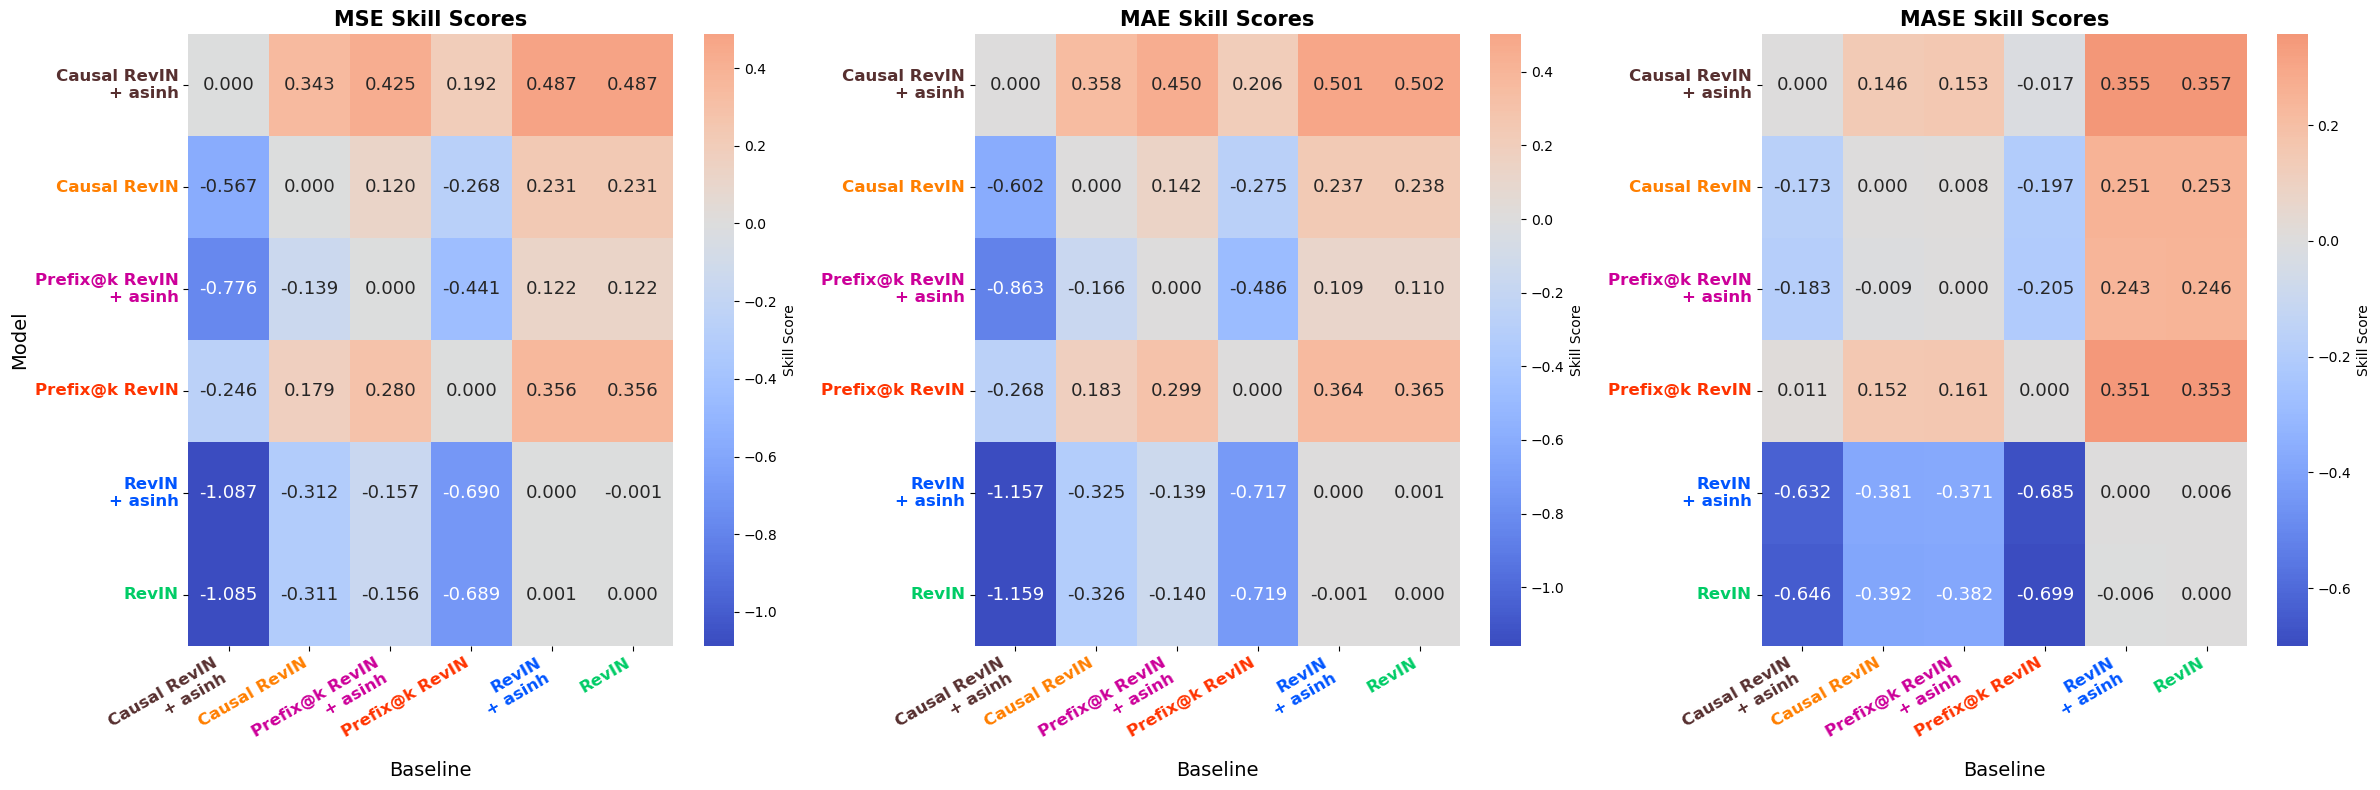

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

model_name_to_show_label = {
    "CausalRevIN_True": "Causal RevIN + asinh",
    "CausalRevIN_False": "Causal RevIN",
    "RevIN_True": "RevIN + asinh",
    "RevIN_False": "RevIN",
    "PrefixRevIN_True": "Prefix@k RevIN + asinh",
    "PrefixRevIN_False": "Prefix@k RevIN"
}

dic_model_colors = {
    "Causal RevIN":          "#FF7F00",  # vivid orange
    "Causal RevIN + asinh":  "#573030FF",  # semi-transparent brown
    "RevIN":                 "#00CC66",  # vivid green
    "RevIN + asinh":         "#0055FF",  # electric deep blue
    "Prefix@k RevIN":        "#FF3300",  # bright red-orange
    "Prefix@k RevIN + asinh": "#CC0099",  # strong magenta
}

def load_npz(filepath):
    """Load npz file and return as dictionary"""
    return np.load(filepath)

# Model names
models = ["CausalRevIN_True", "CausalRevIN_False", "PrefixRevIN_True", 
          "PrefixRevIN_False", "RevIN_True", "RevIN_False"]

context_lengths = ["128", "256", "512"]
datasets = ["utsd", "gift_eval", "artificial"]

# Dictionary to store aggregated matrices (averaged across context lengths)
aggregated_skill_scores = {
    'mse': np.zeros((len(models), len(models))),
    'mae': np.zeros((len(models), len(models))),
    'mase': np.zeros((len(models), len(models)))
}

# Iterate through all context lengths
for context in context_lengths:
    print(f"\n{'='*50}")
    print(f"Processing context length: {context}")
    print(f"{'='*50}")
    
    # Initialize matrices to store skill scores
    skill_scores_mse_matrix = np.zeros((len(models), len(models)))
    skill_scores_mae_matrix = np.zeros((len(models), len(models)))
    skill_scores_mase_matrix = np.zeros((len(models), len(models)))
    
    # Iterate through all baseline-comparison pairs
    for i, baseline in enumerate(models):
        for j, comparison in enumerate(models):
            mse_baseline = []
            mae_baseline = []
            mase_baseline = []
            mse_comparison = []
            mae_comparison = []
            mase_comparison = []
            
            # Load data for each dataset
            for dataset in datasets:
                try:
                    r_baseline = load_npz(f'../processed_results/{baseline}/{context}/results_{dataset}.npz')
                    r_comparison = load_npz(f'../processed_results/{comparison}/{context}/results_{dataset}.npz')
                    
                    # Process metrics
                    for k1, k2 in zip(r_baseline, r_comparison):
                        assert k1 == k2, "Predictions do not match"
                        metric = k1.split("_")[0].lower()
                        
                        if metric == "rmse":
                            mse_baseline.append(r_baseline[k1].item())
                            mse_comparison.append(r_comparison[k2].item())
                        elif metric == "mae":
                            mae_baseline.append(r_baseline[k1].item())
                            mae_comparison.append(r_comparison[k2].item())
                        else:
                            mase_baseline.append(r_baseline[k1].item())
                            mase_comparison.append(r_comparison[k2].item())
                except FileNotFoundError:
                    print(f"Warning: Files not found for {baseline} or {comparison} on {dataset}")
                    continue
            
            # Calculate MSE skill score
            if len(mse_baseline) > 0 and len(mse_comparison) > 0:
                scores_mse = []
                for p1, p2 in zip(mse_baseline, mse_comparison):
                    scores_mse.append(p2/p1)
                scores_mse = np.array(scores_mse)
                scores_mse = np.clip(scores_mse, 0.01, 100)
                n = len(scores_mse)
                produit = np.prod(scores_mse)
                geometric_mean = produit ** (1/n)
                skill_scores_mse = 1 - geometric_mean
                skill_scores_mse_matrix[i, j] = skill_scores_mse
            
            # Calculate MAE skill score
            if len(mae_baseline) > 0 and len(mae_comparison) > 0:
                scores_mae = []
                for p1, p2 in zip(mae_baseline, mae_comparison):
                    scores_mae.append(p2/p1)
                scores_mae = np.array(scores_mae)
                scores_mae = np.clip(scores_mae, 0.01, 100)
                n = len(scores_mae)
                produit = np.prod(scores_mae)
                geometric_mean = produit ** (1/n)
                skill_scores_mae = 1 - geometric_mean
                skill_scores_mae_matrix[i, j] = skill_scores_mae
            
            # Calculate MASE skill score
            if len(mase_baseline) > 0 and len(mase_comparison) > 0:
                scores_mase = []
                for p1, p2 in zip(mase_baseline, mase_comparison):
                    scores_mase.append(p2/p1)
                scores_mase = np.array(scores_mase)
                scores_mase = np.clip(scores_mase, 0.01, 100)
                n = len(scores_mase)
                produit = np.prod(scores_mase)
                geometric_mean = produit ** (1/n)
                skill_scores_mase = 1 - geometric_mean
                skill_scores_mase_matrix[i, j] = skill_scores_mase
            
            print(f"{baseline} vs {comparison} - MSE: {skill_scores_mse_matrix[i,j]:.4f}, "
                  f"MAE: {skill_scores_mae_matrix[i,j]:.4f}, MASE: {skill_scores_mase_matrix[i,j]:.4f}")
    
    # Accumulate skill scores across context lengths (transposed so y=comparison, x=baseline)
    aggregated_skill_scores['mse'] += skill_scores_mse_matrix.T
    aggregated_skill_scores['mae'] += skill_scores_mae_matrix.T
    aggregated_skill_scores['mase'] += skill_scores_mase_matrix.T

# Average the skill scores across all context lengths
aggregated_skill_scores['mse'] /= len(context_lengths)
aggregated_skill_scores['mae'] /= len(context_lengths)
aggregated_skill_scores['mase'] /= len(context_lengths)

print("\n" + "="*50)
print("Aggregated skill scores across all context lengths")
print("="*50)

# Create heatmaps - 1 row x 3 columns (one for each metric)
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Map model names to display labels (split long names with + asinh into two rows)
display_names = []
for m in models:
    label = model_name_to_show_label[m]
    if '+ asinh' in label:
        # Split into two rows
        label = label.replace(' + asinh', '\n+ asinh')
    display_names.append(label)

# MSE Heatmap (averaged across context lengths)
sns.heatmap(aggregated_skill_scores['mse'], annot=True, fmt='.3f', cmap='coolwarm', 
            xticklabels=display_names, yticklabels=display_names, 
            center=0, ax=axes[0], cbar_kws={'label': 'Skill Score'},
            annot_kws={'fontsize': 13})
axes[0].set_title(f'MSE Skill Scores', 
                           fontsize=15, fontweight='bold')
axes[0].set_xlabel('Baseline', fontsize=14)
axes[0].set_ylabel('Model', fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].tick_params(axis='both', labelsize=12)

# Color the tick labels
for label in axes[0].get_xticklabels():
    original_text = label.get_text().replace('\n', ' ')
    label.set_color(dic_model_colors[original_text])
    label.set_fontweight('bold')
for label in axes[0].get_yticklabels():
    original_text = label.get_text().replace('\n', ' ')
    label.set_color(dic_model_colors[original_text])
    label.set_fontweight('bold')

# MAE Heatmap (averaged across context lengths)
sns.heatmap(aggregated_skill_scores['mae'], annot=True, fmt='.3f', cmap='coolwarm', 
            xticklabels=display_names, yticklabels=display_names, 
            center=0, ax=axes[1], cbar_kws={'label': 'Skill Score'},
            annot_kws={'fontsize': 13})
axes[1].set_title(f'MAE Skill Scores', 
                           fontsize=15, fontweight='bold')
axes[1].set_xlabel('Baseline', fontsize=14)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].tick_params(axis='both', labelsize=12)

# Color the tick labels
for label in axes[1].get_xticklabels():
    original_text = label.get_text().replace('\n', ' ')
    label.set_color(dic_model_colors[original_text])
    label.set_fontweight('bold')
for label in axes[1].get_yticklabels():
    original_text = label.get_text().replace('\n', ' ')
    label.set_color(dic_model_colors[original_text])
    label.set_fontweight('bold')

# MASE Heatmap (averaged across context lengths)
sns.heatmap(aggregated_skill_scores['mase'], annot=True, fmt='.3f', cmap='coolwarm', 
            xticklabels=display_names, yticklabels=display_names, 
            center=0, ax=axes[2], cbar_kws={'label': 'Skill Score'},
            annot_kws={'fontsize': 13})
axes[2].set_title(f'MASE Skill Scores', 
                           fontsize=15, fontweight='bold')
axes[2].set_xlabel('Baseline', fontsize=14)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')
axes[2].tick_params(axis='both', labelsize=12)

# Color the tick labels
for label in axes[2].get_xticklabels():
    original_text = label.get_text().replace('\n', ' ')
    label.set_color(dic_model_colors[original_text])
    label.set_fontweight('bold')
for label in axes[2].get_yticklabels():
    original_text = label.get_text().replace('\n', ' ')
    label.set_color(dic_model_colors[original_text])
    label.set_fontweight('bold')

plt.tight_layout()

CausalRevIN_True vs CausalRevIN_True - RMSE: 0.0000, MAE: 0.0000, MASE: 0.0000
CausalRevIN_True vs CausalRevIN_False - RMSE: -0.5451, MAE: -0.5793, MASE: -0.1719
CausalRevIN_True vs PrefixRevIN_True - RMSE: -0.7579, MAE: -0.8411, MASE: -0.1818
CausalRevIN_True vs PrefixRevIN_False - RMSE: -0.2421, MAE: -0.2632, MASE: 0.0138
CausalRevIN_True vs RevIN_True - RMSE: -1.0182, MAE: -1.0812, MASE: -0.5911
CausalRevIN_True vs RevIN_False - RMSE: -1.0168, MAE: -1.0835, MASE: -0.6002


CausalRevIN_False vs CausalRevIN_True - RMSE: 0.3528, MAE: 0.3668, MASE: 0.1467
CausalRevIN_False vs CausalRevIN_False - RMSE: 0.0000, MAE: 0.0000, MASE: 0.0000
CausalRevIN_False vs PrefixRevIN_True - RMSE: -0.1377, MAE: -0.1658, MASE: -0.0084
CausalRevIN_False vs PrefixRevIN_False - RMSE: 0.1961, MAE: 0.2001, MASE: 0.1585
CausalRevIN_False vs RevIN_True - RMSE: -0.3062, MAE: -0.3178, MASE: -0.3577
CausalRevIN_False vs RevIN_False - RMSE: -0.3053, MAE: -0.3193, MASE: -0.3655
PrefixRevIN_True vs CausalRevIN_True - RMSE: 0.4311, MAE: 0.4568, MASE: 0.1538
PrefixRevIN_True vs CausalRevIN_False - RMSE: 0.1210, MAE: 0.1422, MASE: 0.0084
PrefixRevIN_True vs PrefixRevIN_True - RMSE: 0.0000, MAE: 0.0000, MASE: 0.0000
PrefixRevIN_True vs PrefixRevIN_False - RMSE: 0.2934, MAE: 0.3139, MASE: 0.1655
PrefixRevIN_True vs RevIN_True - RMSE: -0.1481, MAE: -0.1304, MASE: -0.3463
PrefixRevIN_True vs RevIN_False - RMSE: -0.1473, MAE: -0.1317, MASE: -0.3541
PrefixRevIN_False vs CausalRevIN_True - RMSE: 0.1

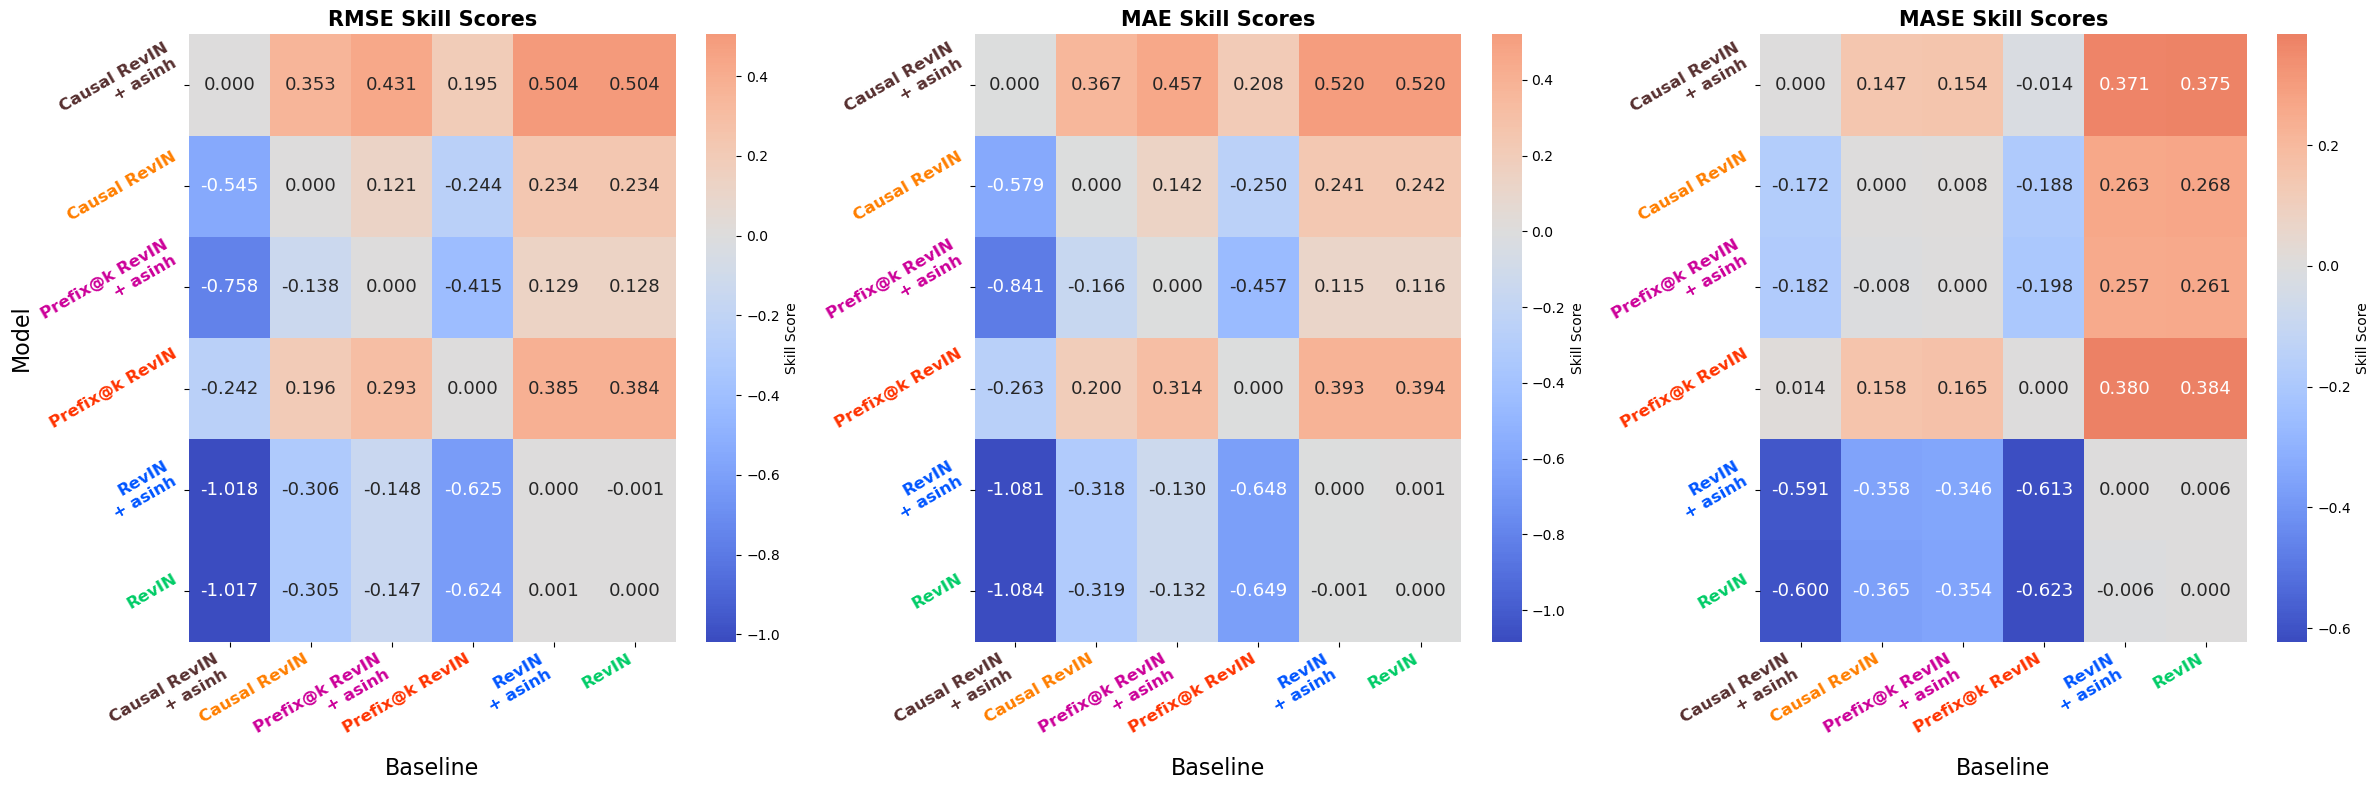

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

model_name_to_show_label = {
    "CausalRevIN_True": "Causal RevIN + asinh",
    "CausalRevIN_False": "Causal RevIN",
    "RevIN_True": "RevIN + asinh",
    "RevIN_False": "RevIN",
    "PrefixRevIN_True": "Prefix@k RevIN + asinh",
    "PrefixRevIN_False": "Prefix@k RevIN"
}

dic_model_colors = {
    "Causal RevIN":          "#FF7F00",  # vivid orange
    "Causal RevIN + asinh":  "#573030FF",  # semi-transparent brown
    "RevIN":                 "#00CC66",  # vivid green
    "RevIN + asinh":         "#0055FF",  # electric deep blue
    "Prefix@k RevIN":        "#FF3300",  # bright red-orange
    "Prefix@k RevIN + asinh": "#CC0099",  # strong magenta
}

def load_npz(filepath):
    """Load npz file and return as dictionary"""
    return np.load(filepath)

# Model names
models = ["CausalRevIN_True", "CausalRevIN_False", "PrefixRevIN_True", 
          "PrefixRevIN_False", "RevIN_True", "RevIN_False"]

context_lengths = ["128", "256", "512"]
datasets = ["utsd", "gift_eval", "artificial"]

# Dictionary to store aggregated matrices (averaged across context lengths)
aggregated_skill_scores = {
    'mse': np.zeros((len(models), len(models))),
    'mae': np.zeros((len(models), len(models))),
    'mase': np.zeros((len(models), len(models)))
}

skill_scores_mse_matrix = np.zeros((len(models), len(models)))
skill_scores_mae_matrix = np.zeros((len(models), len(models)))
skill_scores_mase_matrix = np.zeros((len(models), len(models)))

# Iterate through all baseline-comparison pairs
for i, baseline in enumerate(models):
    for j, comparison in enumerate(models):
        mse_baseline = []
        mae_baseline = []
        mase_baseline = []
        mse_comparison = []
        mae_comparison = []
        mase_comparison = []
        
        # Load data for each dataset
        for dataset in datasets:
            for context in context_lengths:
                try:
                    r_baseline = load_npz(f'../processed_results/{baseline}/{context}/results_{dataset}.npz')
                    r_comparison = load_npz(f'../processed_results/{comparison}/{context}/results_{dataset}.npz')
                    
                    # Process metrics
                    for k1, k2 in zip(r_baseline, r_comparison):
                        assert k1 == k2, "Predictions do not match"
                        metric = k1.split("_")[0].lower()
                        
                        if metric == "rmse":
                            mse_baseline.append(r_baseline[k1].item())
                            mse_comparison.append(r_comparison[k2].item())
                        elif metric == "mae":
                            mae_baseline.append(r_baseline[k1].item())
                            mae_comparison.append(r_comparison[k2].item())
                        else:
                            mase_baseline.append(r_baseline[k1].item())
                            mase_comparison.append(r_comparison[k2].item())
                except FileNotFoundError:
                    print(f"Warning: Files not found for {baseline} or {comparison} on {dataset}")
                    continue
        
        # Calculate MSE skill score
        if len(mse_baseline) > 0 and len(mse_comparison) > 0:
            scores_mse = []
            for p1, p2 in zip(mse_baseline, mse_comparison):
                scores_mse.append(p2/p1)
            scores_mse = np.array(scores_mse)
            scores_mse = np.clip(scores_mse, 0.01, 100)
            n = len(scores_mse)
            produit = np.prod(scores_mse)
            geometric_mean = produit ** (1/n)
            skill_scores_mse = 1 - geometric_mean
            skill_scores_mse_matrix[i, j] = skill_scores_mse
        
        # Calculate MAE skill score
        if len(mae_baseline) > 0 and len(mae_comparison) > 0:
            scores_mae = []
            for p1, p2 in zip(mae_baseline, mae_comparison):
                scores_mae.append(p2/p1)
            scores_mae = np.array(scores_mae)
            scores_mae = np.clip(scores_mae, 0.01, 100)
            n = len(scores_mae)
            produit = np.prod(scores_mae)
            geometric_mean = produit ** (1/n)
            skill_scores_mae = 1 - geometric_mean
            skill_scores_mae_matrix[i, j] = skill_scores_mae
        
        # Calculate MASE skill score
        if len(mase_baseline) > 0 and len(mase_comparison) > 0:
            scores_mase = []
            for p1, p2 in zip(mase_baseline, mase_comparison):
                scores_mase.append(p2/p1)
            scores_mase = np.array(scores_mase)
            scores_mase = np.clip(scores_mase, 0.01, 100)
            n = len(scores_mase)
            produit = np.prod(scores_mase)
            geometric_mean = produit ** (1/n)
            skill_scores_mase = 1 - geometric_mean
            skill_scores_mase_matrix[i, j] = skill_scores_mase
        
        print(f"{baseline} vs {comparison} - RMSE: {skill_scores_mse_matrix[i,j]:.4f}, "
              f"MAE: {skill_scores_mae_matrix[i,j]:.4f}, MASE: {skill_scores_mase_matrix[i,j]:.4f}")

# Transpose matrices so y=comparison, x=baseline
aggregated_skill_scores['mse'] = skill_scores_mse_matrix.T
aggregated_skill_scores['mae'] = skill_scores_mae_matrix.T
aggregated_skill_scores['mase'] = skill_scores_mase_matrix.T

print("\n" + "="*50)
print("Aggregated skill scores across all context lengths")
print("="*50)

# Create heatmaps - 1 row x 3 columns (one for each metric)
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Map model names to display labels (split long names with + asinh into two rows)
display_names = []
for m in models:
    label = model_name_to_show_label[m]
    if '+ asinh' in label:
        # Split into two rows
        label = label.replace(' + asinh', '\n+ asinh')
    display_names.append(label)

# MSE Heatmap (averaged across context lengths)
sns.heatmap(aggregated_skill_scores['mse'], annot=True, fmt='.3f', cmap='coolwarm', 
            xticklabels=display_names, yticklabels=display_names, 
            center=0, ax=axes[0], cbar_kws={'label': 'Skill Score'},
            annot_kws={'fontsize': 13})
axes[0].set_title(f'RMSE Skill Scores', 
                           fontsize=15, fontweight='bold')
axes[0].set_xlabel('Baseline', fontsize=16)
axes[0].set_ylabel('Model', fontsize=16)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=30, ha='right')
axes[0].tick_params(axis='both', labelsize=12)

# Color the tick labels
for label in axes[0].get_xticklabels():
    original_text = label.get_text().replace('\n', ' ')
    label.set_color(dic_model_colors[original_text])
    label.set_fontweight('bold')
for label in axes[0].get_yticklabels():
    original_text = label.get_text().replace('\n', ' ')
    label.set_color(dic_model_colors[original_text])
    label.set_fontweight('bold')

# MAE Heatmap (averaged across context lengths)
sns.heatmap(aggregated_skill_scores['mae'], annot=True, fmt='.3f', cmap='coolwarm', 
            xticklabels=display_names, yticklabels=display_names, 
            center=0, ax=axes[1], cbar_kws={'label': 'Skill Score'},
            annot_kws={'fontsize': 13})
axes[1].set_title(f'MAE Skill Scores', 
                           fontsize=15, fontweight='bold')
axes[1].set_xlabel('Baseline', fontsize=16)
#axes[1].set_ylabel('Model', fontsize=16)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=30, ha='right')
axes[1].tick_params(axis='both', labelsize=12)

# Color the tick labels
for label in axes[1].get_xticklabels():
    original_text = label.get_text().replace('\n', ' ')
    label.set_color(dic_model_colors[original_text])
    label.set_fontweight('bold')
for label in axes[1].get_yticklabels():
    original_text = label.get_text().replace('\n', ' ')
    label.set_color(dic_model_colors[original_text])
    label.set_fontweight('bold')

# MASE Heatmap (averaged across context lengths)
sns.heatmap(aggregated_skill_scores['mase'], annot=True, fmt='.3f', cmap='coolwarm', 
            xticklabels=display_names, yticklabels=display_names, 
            center=0, ax=axes[2], cbar_kws={'label': 'Skill Score'},
            annot_kws={'fontsize': 13})
axes[2].set_title(f'MASE Skill Scores', 
                           fontsize=15, fontweight='bold')
axes[2].set_xlabel('Baseline', fontsize=16)
#axes[2].set_ylabel('Model', fontsize=16)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')
axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=30, ha='right')
axes[2].tick_params(axis='both', labelsize=12)

# Color the tick labels
for label in axes[2].get_xticklabels():
    original_text = label.get_text().replace('\n', ' ')
    label.set_color(dic_model_colors[original_text])
    label.set_fontweight('bold')
for label in axes[2].get_yticklabels():
    original_text = label.get_text().replace('\n', ' ')
    label.set_color(dic_model_colors[original_text])
    label.set_fontweight('bold')

plt.tight_layout()
